In [1]:
import numpy as np
import matplotlib.pyplot as plt

class SpringSystem:

    def __init__(self, k, m):
        self.k = k
        self.m = m
    
    def force(self, q):
        return -self.k * q
    
    def potential(self, q):
        return 0.5 * self.k * q**2

In [2]:
x0 = 3 # Initial position 
p0 = 0 # Initial momentum
sys = SpringSystem(2, 4) # Spring system with k = 2 and m = 4
dt = 0.01 # Timestep of the simulation
nsteps = 1000 # Number of timesteps of the simulation

In [3]:
def propagator(q, p, F, m, dt):
    """
    q -> scalar number of position
    p -> scalar number of momentum
    F -> the force function which takes as input the position of the system and returns the force value
    m -> scalar value denoting the mass of the particle
    dt -> the timestep of the system
    """
    force_old = F(q)
    q = q + dt * p / m + 0.5 * dt**2 * force_old / m
    force_new = F(q)
    p = p + 0.5 * dt * (force_old + force_new)
    return q, p

In [4]:
q = x0
p = p0

positions = []
momentums = []
times = []

for i in range(nsteps):
    t = dt * i
    positions.append(q)
    momentums.append(p)
    times.append(t)
    q, p = propagator(q, p, sys.force, sys.m, dt)

positions = np.array(positions)
momentums = np.array(momentums)
times = np.array(times)

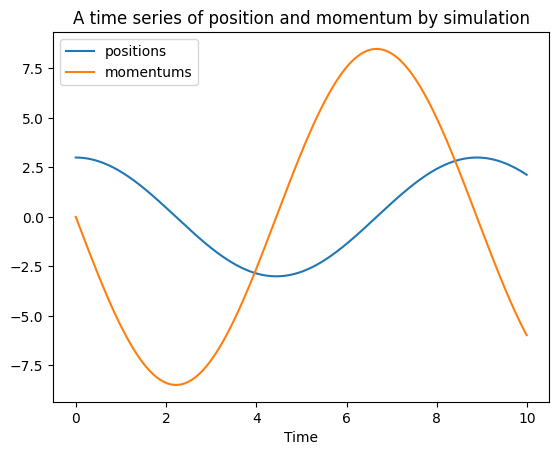

In [5]:
plt.plot(times, positions, label = 'positions')
plt.plot(times, momentums, label = 'momentums')

plt.legend(loc = 'best')
plt.xlabel('Time')

plt.title('A time series of position and momentum by simulation')
plt.savefig('simulation_graph.png')

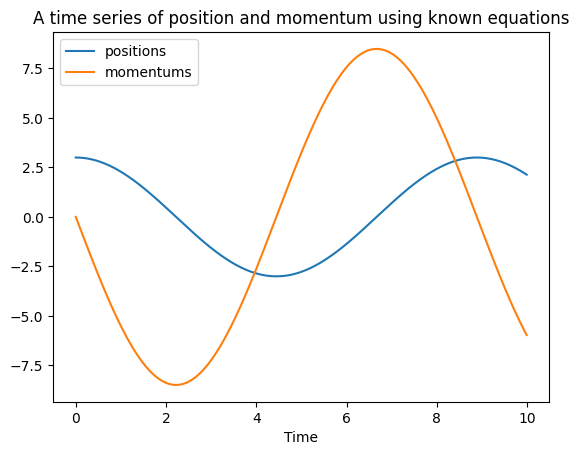

In [6]:
position_known = 3 * np.cos(0.707 * times)
momentum_known = -8.484 * np.sin(0.707 * times)

plt.plot(times, position_known, label = 'positions')
plt.plot(times, momentum_known, label = 'momentums')

plt.legend(loc = 'best')
plt.xlabel('Time')

plt.title('A time series of position and momentum using known equations')
plt.savefig('known_graph.png')

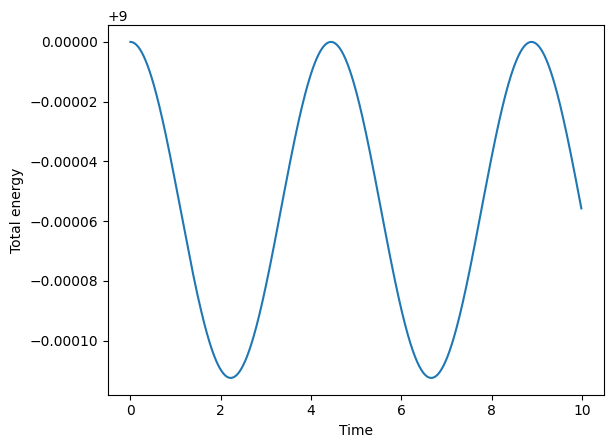

In [7]:
total_energy = 0.5 * sys.k * positions**2 + 0.5 * momentums**2 / sys.m


plt.plot(times, total_energy)

plt.xlabel('Time')
plt.ylabel('Total energy')
plt.savefig('total_energy_graph.png')